In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression,ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error,root_mean_squared_error,confusion_matrix,roc_auc_score,log_loss
from sklearn.metrics import f1_score,accuracy_score,recall_score,precision_score,classification_report
from tqdm import tqdm
import os
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler,PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
import datetime as dt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis,QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import BernoulliNB,GaussianNB
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer,make_column_selector
from sklearn.tree import DecisionTreeClassifier,plot_tree,DecisionTreeRegressor

In [8]:
housing = pd.read_csv(r'../../Datasets/Housing.csv')
housing

,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,42000.0,5850,3,1,2,yes,no,yes,no,no,1,no
1,38500.0,4000,2,1,1,yes,no,no,no,no,0,no
2,49500.0,3060,3,1,1,yes,no,no,no,no,0,no
3,60500.0,6650,3,1,2,yes,yes,no,no,no,0,no
4,61000.0,6360,2,1,1,yes,no,no,no,no,0,no
...,...,...,...,...,...,...,...,...,...,...,...,...
541,91500.0,4800,3,2,4,yes,yes,no,no,yes,0,no
542,94000.0,6000,3,2,4,yes,no,no,no,yes,0,no
543,103000.0,6000,3,2,4,yes,yes,no,no,yes,1,no
544,105000.0,6000,3,2,2,yes,yes,no,no,yes,1,no


In [10]:
X = housing.drop('price',axis=1)
y=housing['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=26)

In [15]:
ohe=OneHotEncoder(sparse_output=False,drop="first").set_output(transform="pandas")
trans = ColumnTransformer(
    transformers=[("OHE", ohe,make_column_selector(dtype_include=object))],remainder="passthrough",
    verbose_feature_names_out=False).set_output(transform="pandas")
X_trn_ohe = trans.fit_transform(X_train)
X_tst_ohe = trans.transform(X_test)


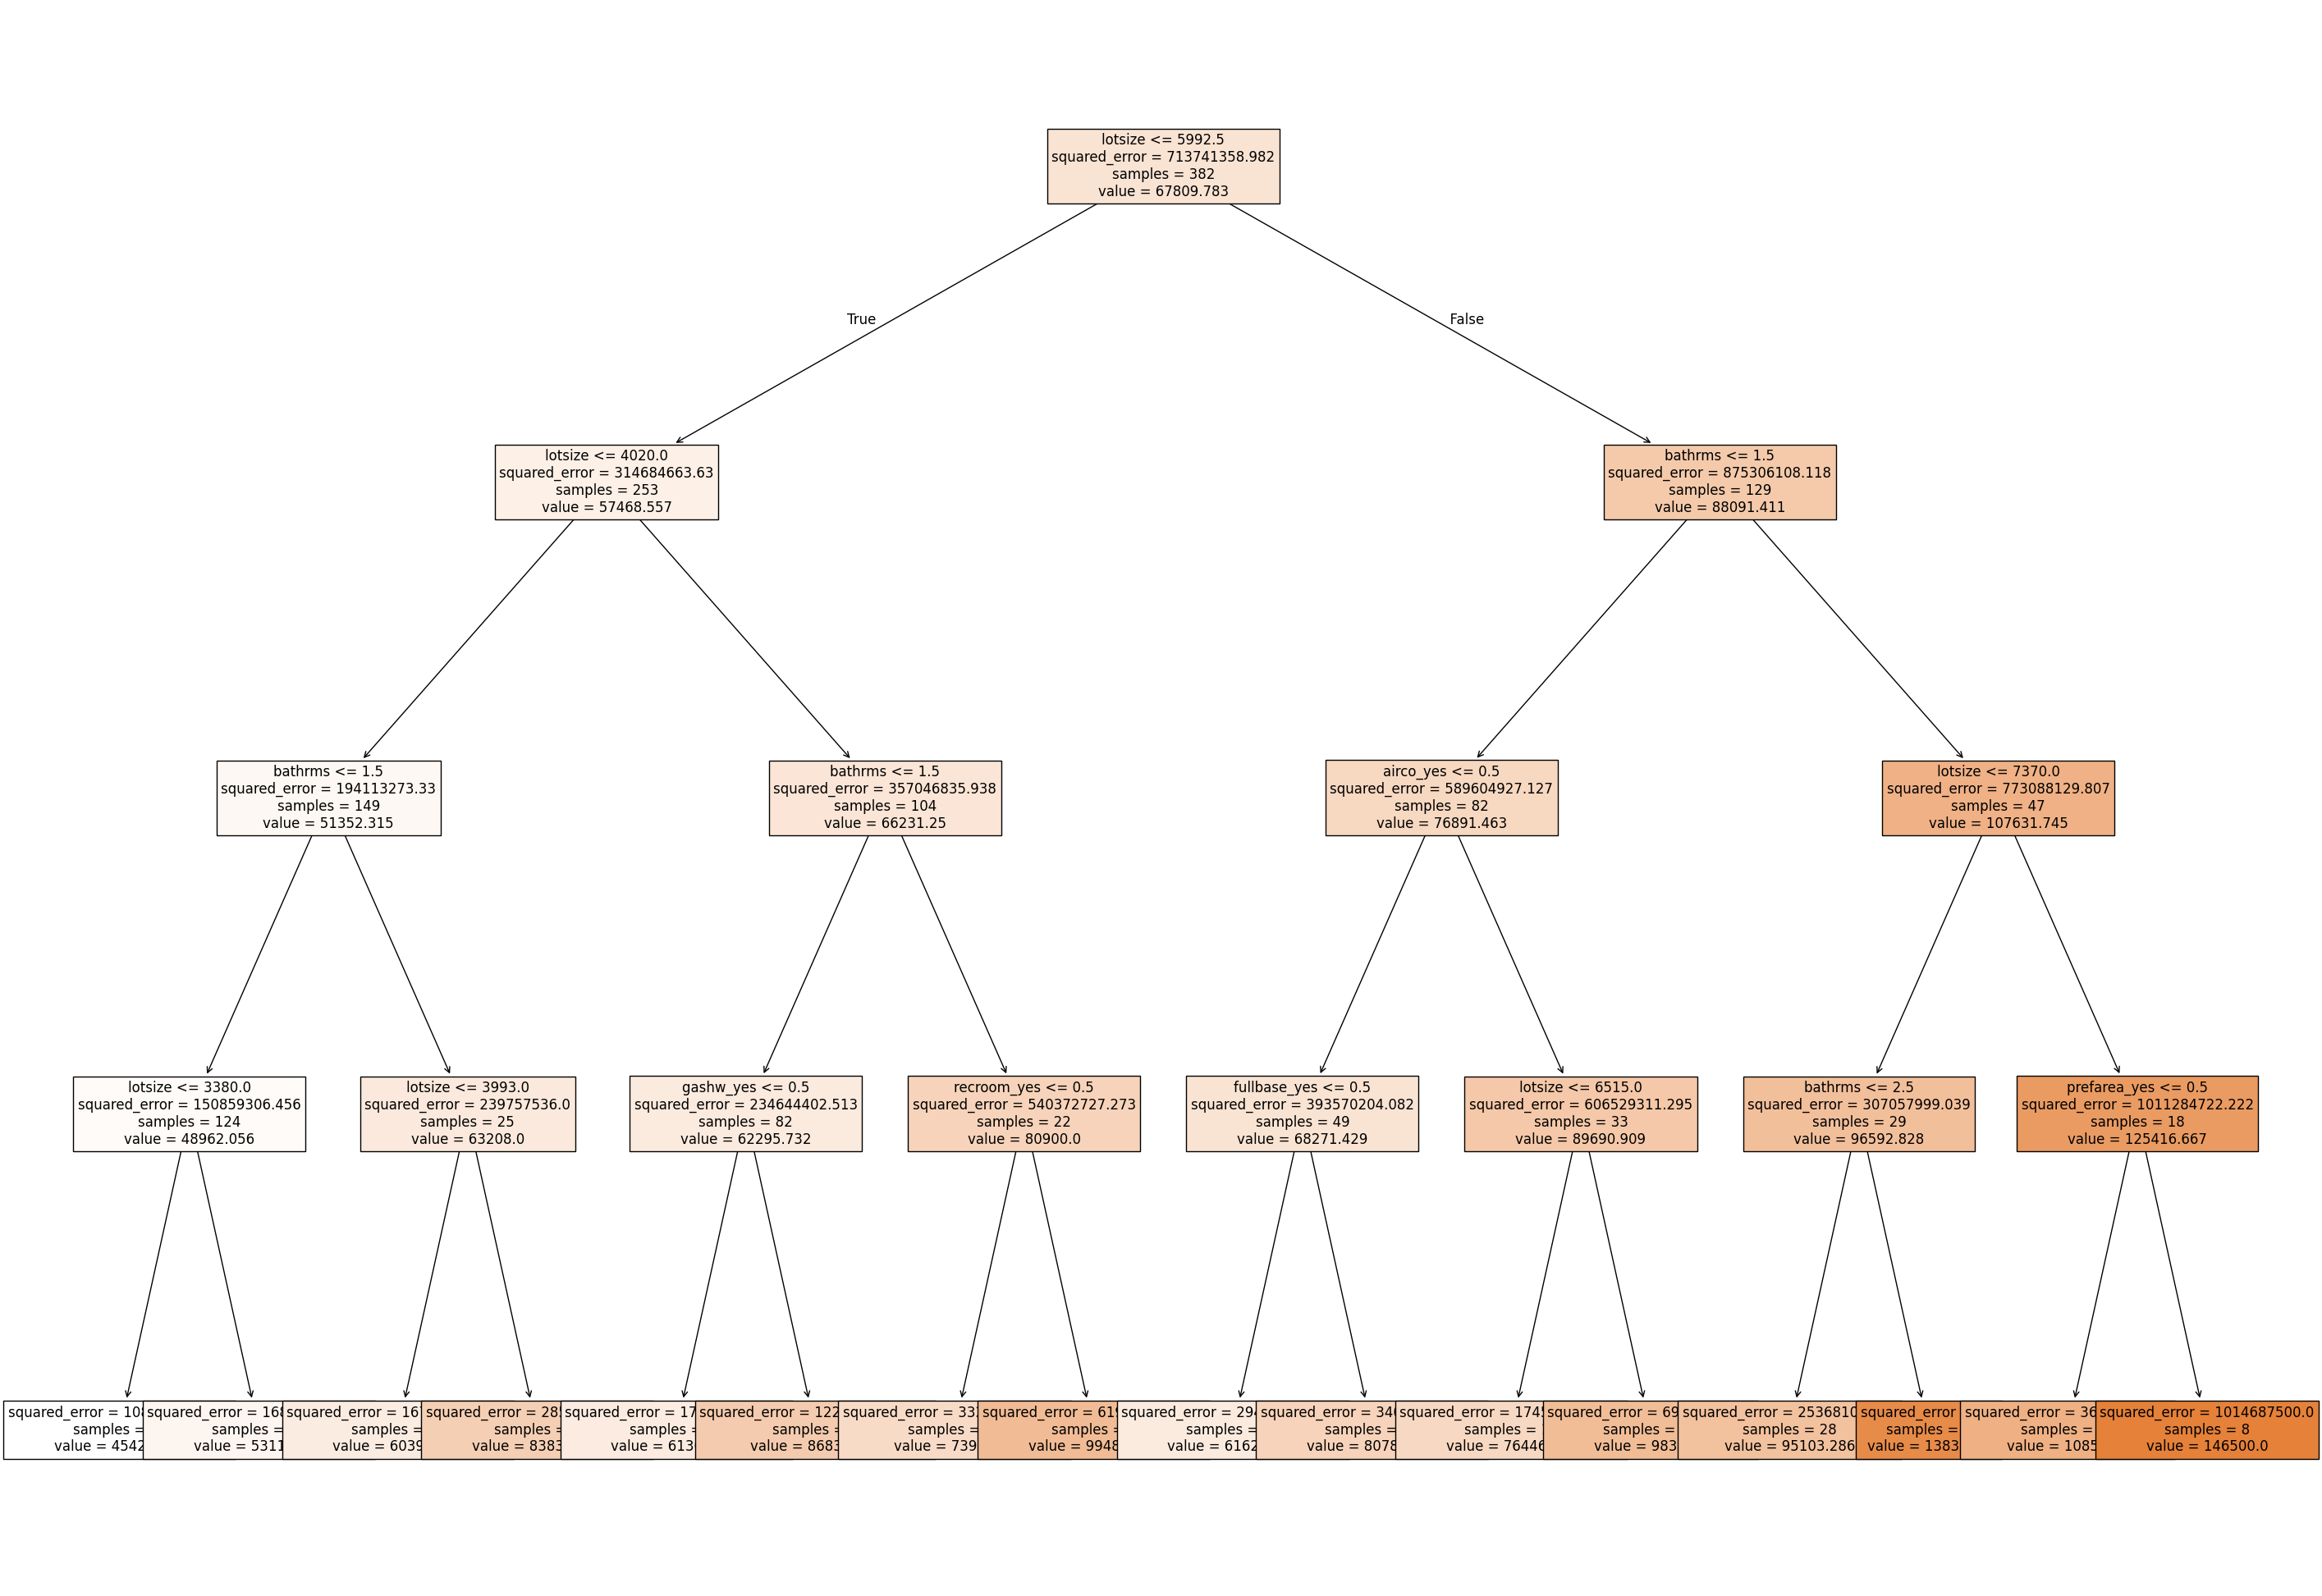

In [16]:
dtc = DecisionTreeRegressor(random_state=26,max_depth=4)
dtc.fit(X_trn_ohe, y_train)

plt.figure(figsize=(35, 25))
plot_tree(dtc, 
          feature_names=list(X_trn_ohe.columns), 
          filled=True, 
          fontsize=12)

plt.show()

In [19]:
depths=[1,2,3,5,None]
splits = [2,4,8,10,20,30,50,100]
leaves = [1,4,8,10,20,30,50,100]
scores=[]
for d in tqdm(depths):
    for s in splits:
        for l in leaves:
            dtc=DecisionTreeRegressor(random_state=26,max_depth=d,min_samples_split=s,min_samples_leaf=l)
            dtc.fit(X_trn_ohe,y_train)
            y_pred=dtc.predict(X_tst_ohe)
            scores.append([d,s,l,r2_score(y_test,y_pred)])


df_scores = pd.DataFrame(scores, columns=['depths', 'splits', 'leaves',  'r2_score'])
df_scores.sort_values('r2_score',ascending=False).head()

  0%|                                                                                            | 0/5 [00:00<?, ?it/s]

 20%|████████████████▊                                                                   | 1/5 [00:00<00:01,  3.96it/s]

 40%|█████████████████████████████████▌                                                  | 2/5 [00:00<00:00,  4.31it/s]

 60%|██████████████████████████████████████████████████▍                                 | 3/5 [00:00<00:00,  4.47it/s]

 80%|███████████████████████████████████████████████████████████████████▏                | 4/5 [00:00<00:00,  4.49it/s]

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:01<00:00,  4.42it/s]

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:01<00:00,  4.39it/s]

,depths,splits,leaves,r2_score
244,5.0,50,20,0.530931
308,NaN,50,20,0.530931
243,5.0,50,10,0.528372
242,5.0,50,8,0.528372
306,NaN,50,8,0.528372


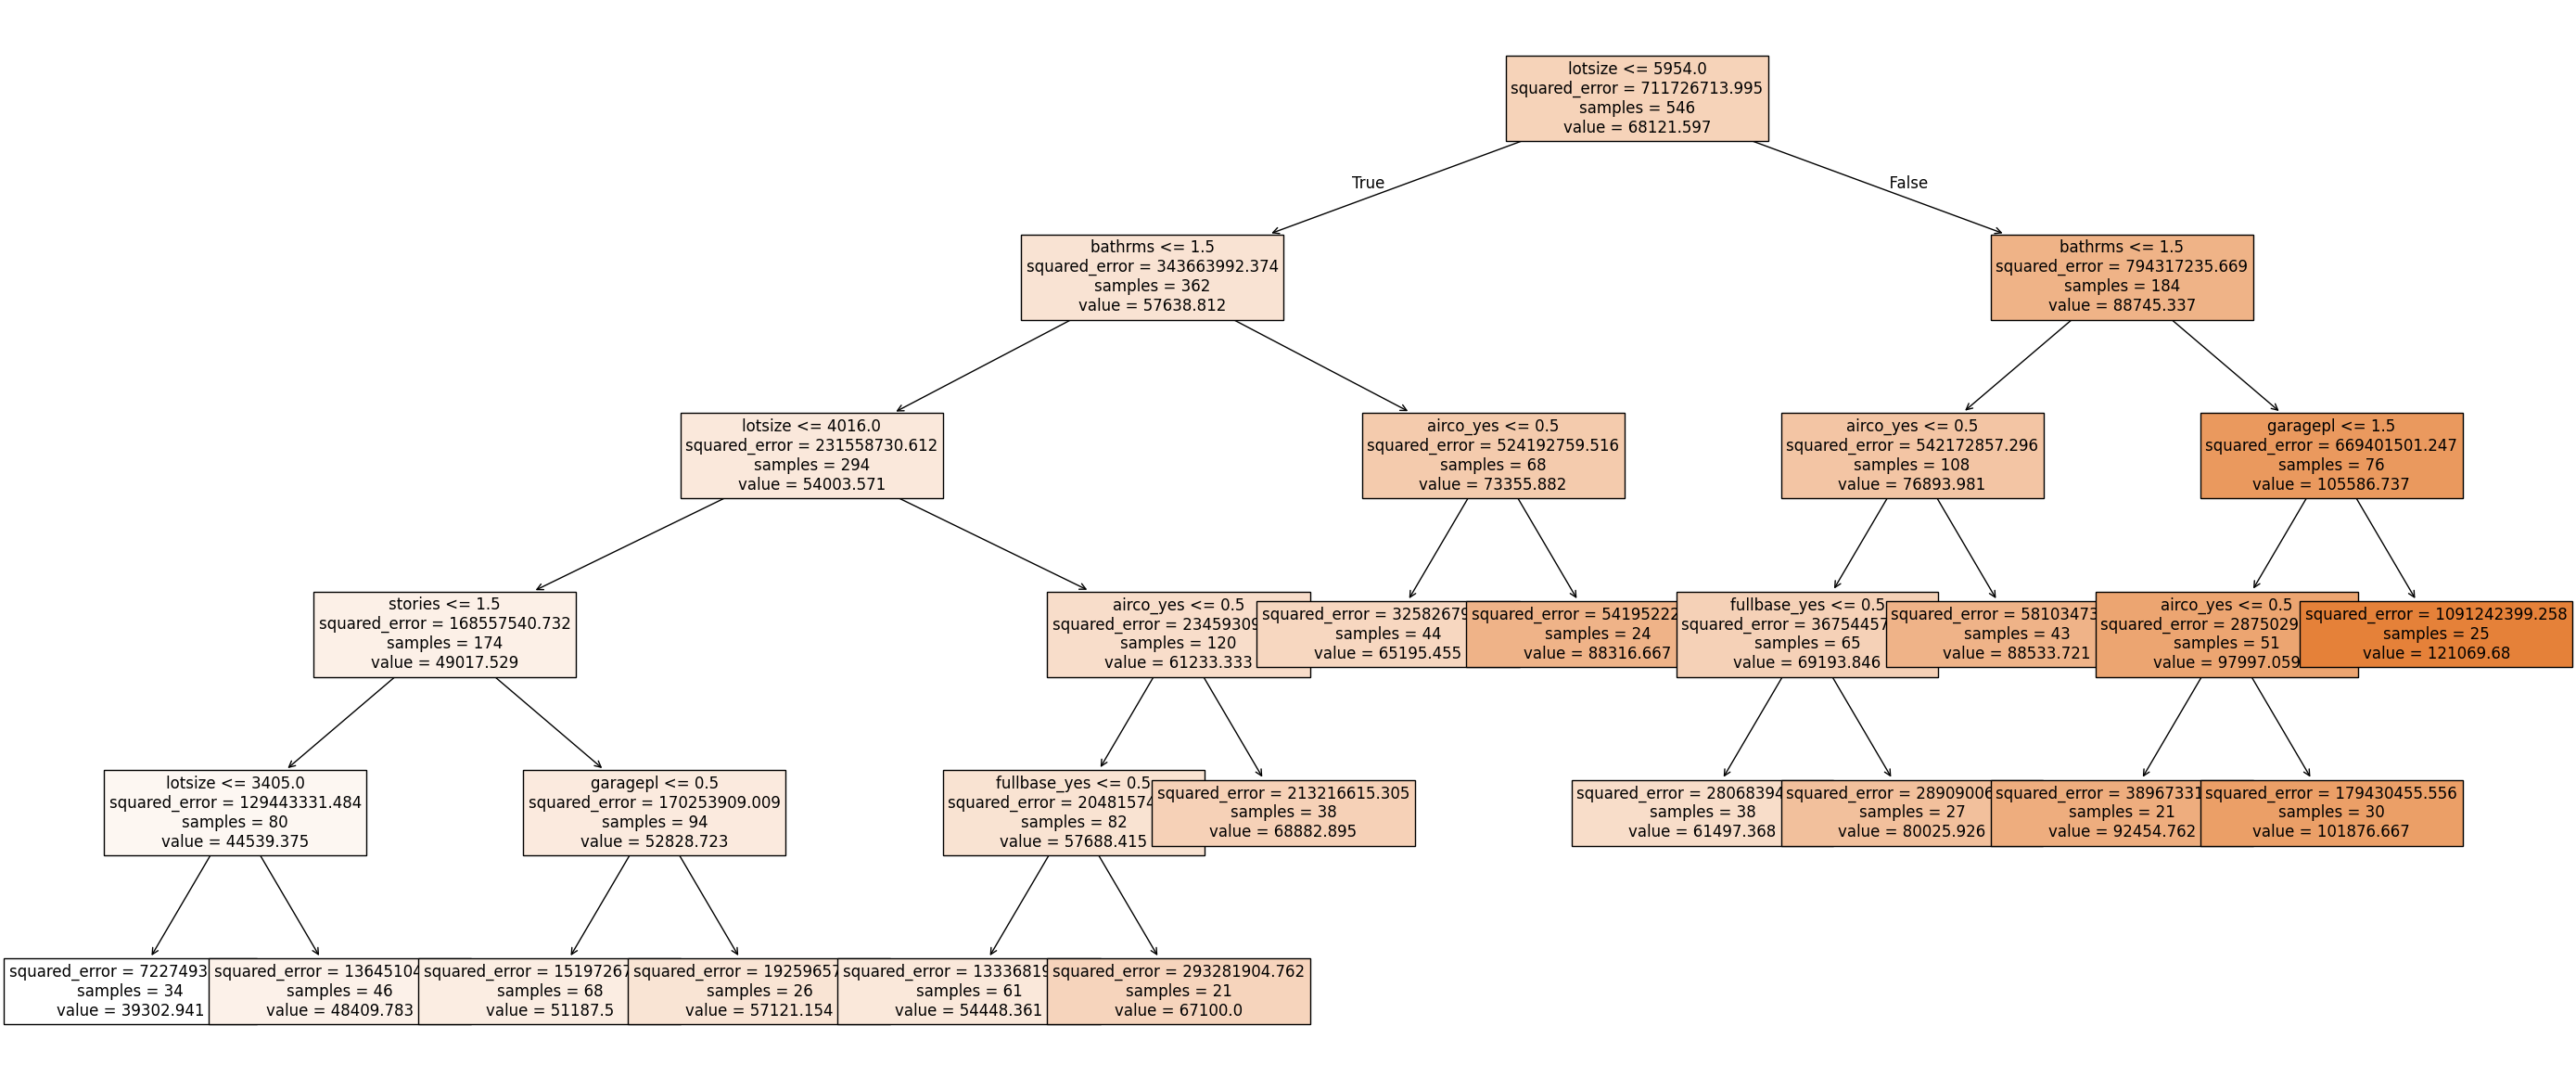

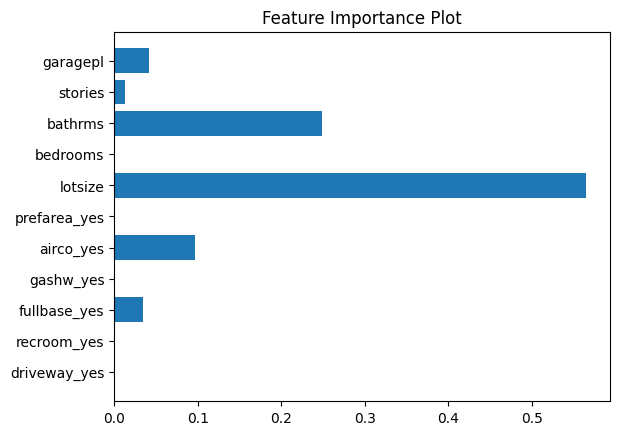

In [23]:
bm = DecisionTreeRegressor(  
                random_state=26,
                min_samples_leaf=20,
                min_samples_split=50,
                max_depth=5
            )
X_ohe=trans.fit_transform(X)

bm.fit(X_ohe, y)
plt.figure(figsize=(35, 15))

plot_tree(bm, feature_names = list(X_ohe.columns), filled = True, fontsize = 12)
plt.show()

df_imp = pd.DataFrame({'feature':X_ohe.columns,'importance':bm.feature_importances_})
plt.barh(df_imp['feature'],df_imp['importance'])
plt.title('Feature Importance Plot')
plt.show()